# Customer Churn Prediction — Model Training & Evaluation

This notebook covers:
- Data preprocessing and feature engineering
- Training Logistic Regression, Random Forest, and XGBoost
- Evaluation using Accuracy, Recall, F1, and ROC-AUC
- Hyperparameter tuning
- Feature importance analysis
- Saving the best model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, f1_score
)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid')
df = pd.read_csv('C:\\Users\\hp\\Documents\\Projects\\Customer Churn Prediction\\data\\WA_Fn-UseC_-Telco-Customer-Churn.csv')
print('Loaded:', df.shape)
df.head()

Loaded: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Preprocessing & Feature Engineering

In [2]:
# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID — not predictive
df.drop('customerID', axis=1, inplace=True)

# Feature Engineering
df['tenure_group'] = pd.cut(df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12mo', '12-24mo', '24-48mo', '48-72mo'])

df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)
df['is_senior_monthly'] = ((df['SeniorCitizen'] == 1) &
                            (df['Contract'] == 'Month-to-month')).astype(int)

# Encode target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print('Features after engineering:', df.shape[1])
df.head()

Features after engineering: 23


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,avg_monthly_spend,is_senior_monthly
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-12mo,14.925000,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,0,24-48mo,53.985714,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-12mo,36.050000,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,24-48mo,40.016304,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-12mo,50.550000,0


In [3]:
# Encode all categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns to encode:', cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print('All columns now numeric. Shape:', df.shape)

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']
All columns now numeric. Shape: (7043, 23)


In [8]:
# Train-Test Split
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('Train size:', X_train.shape, '| Test size:', X_test.shape)
print('Churn rate in train:', round(y_train.mean() * 100, 2), '%')
print('Churn rate in test: ', round(y_test.mean() * 100, 2), '%')

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Scale numerical features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Train size: (5634, 22) | Test size: (1409, 22)
Churn rate in train: 26.54 %
Churn rate in test:  26.54 %


In [9]:


print(np.isnan(X_train_scaled).sum())

0


## 2. Train Multiple Models

In [10]:
# --- Model 1: Logistic Regression ---
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr  = lr.predict(X_test_scaled)
y_prob_lr  = lr.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob_lr), 4))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC: 0.8461


In [11]:
# --- Model 2: Random Forest ---
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf  = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob_rf), 4))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8271


In [12]:
# --- Model 3: XGBoost ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print('=== XGBoost ===')
print(classification_report(y_test, y_pred_xgb))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob_xgb), 4))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409

ROC-AUC: 0.8359


## 3. Model Comparison

                     Accuracy  F1 Score  ROC-AUC
Model                                           
Logistic Regression    0.7438    0.6180   0.8461
Random Forest          0.7871    0.5482   0.8271
XGBoost                0.7615    0.6300   0.8359


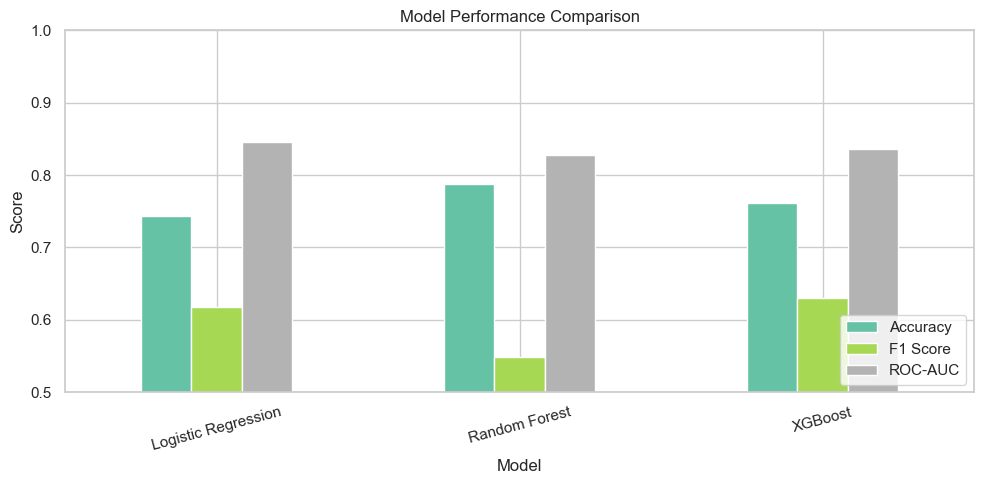

In [13]:
results = {
    'Model':    ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC':  [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
}
results_df = pd.DataFrame(results).set_index('Model').round(4)
print(results_df)

# Plot comparison
results_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4. ROC Curve

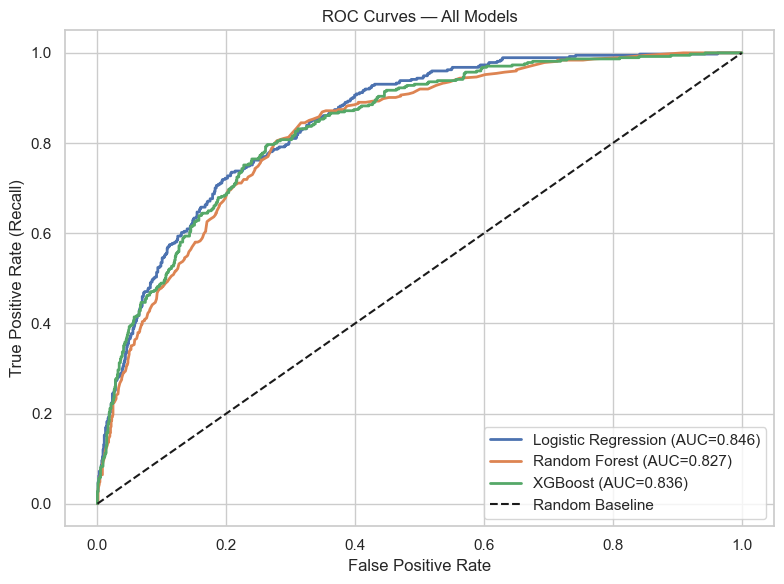

In [14]:
plt.figure(figsize=(8, 6))

for name, y_prob in [('Logistic Regression', y_prob_lr),
                      ('Random Forest', y_prob_rf),
                      ('XGBoost', y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Confusion Matrix — Best Model (XGBoost)

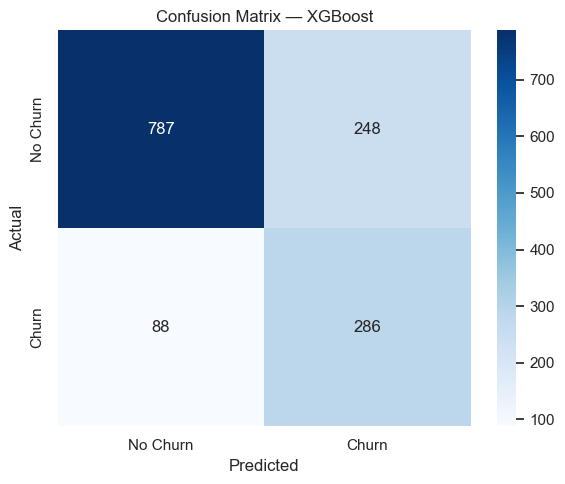

In [15]:
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix — XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning — XGBoost

In [16]:
param_dist = {
    'n_estimators':  [100, 200, 300, 400],
    'max_depth':     [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample':     [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

search = RandomizedSearchCV(
    xgb_base, param_dist,
    n_iter=20, scoring='roc_auc',
    cv=5, random_state=42, n_jobs=-1, verbose=1
)
search.fit(X_train, y_train)

print('Best Params:', search.best_params_)
print('Best CV ROC-AUC:', round(search.best_score_, 4))

best_model = search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]
print('\nTuned XGBoost Test ROC-AUC:', round(roc_auc_score(y_test, y_prob_best), 4))
print(classification_report(y_test, y_pred_best))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best CV ROC-AUC: 0.8474

Tuned XGBoost Test ROC-AUC: 0.8476
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



## 7. Feature Importance

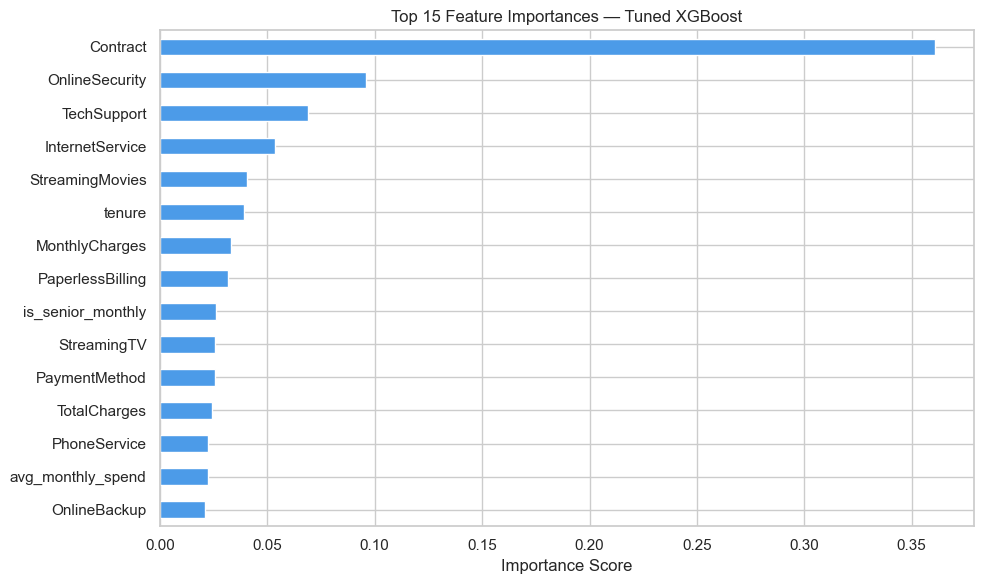

In [17]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh', color='#4C9BE8', edgecolor='white')
plt.title('Top 15 Feature Importances — Tuned XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 8. Save Best Model & Scaler

In [18]:
os.makedirs('../app', exist_ok=True)
joblib.dump(best_model, '../app/best_model.pkl')
joblib.dump(scaler,     '../app/scaler.pkl')
joblib.dump(list(X.columns), '../app/feature_names.pkl')
print('Model, scaler, and feature names saved to ../app/')

Model, scaler, and feature names saved to ../app/
